# DNS Project — Block 4 (Postprocessing) and Block 5 (Evaluation)

**Block 4:** Load trained model → enhance noisy test audio → save enhanced `.wav` files

**Block 5:** Run DNSMOS evaluation on noisy, enhanced (Config A), enhanced (Config B), and baseline ONNX audio

Run all cells top to bottom in order.

## Section 1 — Imports and Setup

In [49]:
import os
import sys
import glob
import subprocess
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# project folder — all scripts live here
PROJECT_DIR = os.path.expanduser('~/nn_proj')
sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla V100-SXM2-32GB


## Section 2 — Constants and Paths

These must match train.py exactly.

In [50]:
# ── STFT constants — must match train.py exactly ──────────────────────────
SAMPLE_RATE = 16_000
DURATION_SEC = 15
N_SAMPLES   = SAMPLE_RATE * DURATION_SEC   # 240,000
FRAME_SIZE  = int(0.02 * SAMPLE_RATE)      # 320 samples = 20ms
HOP_SIZE    = int(0.02 * SAMPLE_RATE * 0.5)  # 160 samples = 10ms
DFT_SIZE    = 320
N_FREQS     = DFT_SIZE // 2 + 1            # 161 frequency bins

# ── Trained model paths ────────────────────────────────────────────────────
CONFIG_A_DIR   = os.path.join(PROJECT_DIR, 'runs', 'samp2000_bs16_lr1em02_hidden161')
CONFIG_B_DIR   = os.path.join(PROJECT_DIR, 'runs', 'samp2000_bs16_lr1em02_hidden322')
CONFIG_A_MODEL = os.path.join(CONFIG_A_DIR, 'best_model.pt')
CONFIG_B_MODEL = os.path.join(CONFIG_B_DIR, 'best_model.pt')

# ── Script paths (from repo) ────────────────────────────────────────────────
# enhance.py is in baseline/ subfolder
ENHANCE_SCRIPT = os.path.join(PROJECT_DIR, 'baseline', 'enhance.py')
if not os.path.exists(ENHANCE_SCRIPT):
    ENHANCE_SCRIPT = os.path.join(PROJECT_DIR, 'enhance.py')
DNSMOS_SCRIPT  = os.path.join(PROJECT_DIR, 'dnsmos_local.py')

# ONNX baseline model (in baseline/ folder)
ONNX_MODEL = os.path.join(PROJECT_DIR, 'baseline', 'dec-baseline-model-icassp2022.onnx')
if not os.path.exists(ONNX_MODEL):
    # try root folder
    ONNX_MODEL = os.path.join(PROJECT_DIR, 'dec-baseline-model-icassp2022.onnx')

# ── Output folders ──────────────────────────────────────────────────────────
ENHANCED_DIR = os.path.join(PROJECT_DIR, 'enhanced_audio')
for d in ['noisy', 'configA', 'configB', 'baseline_onnx']:
    os.makedirs(os.path.join(ENHANCED_DIR, d), exist_ok=True)

# ── Verify everything exists ────────────────────────────────────────────────
print('Config A model :', CONFIG_A_MODEL, '→ exists:', os.path.exists(CONFIG_A_MODEL))
print('Config B model :', CONFIG_B_MODEL, '→ exists:', os.path.exists(CONFIG_B_MODEL))
print('enhance.py     :', ENHANCE_SCRIPT, '→ exists:', os.path.exists(ENHANCE_SCRIPT))
print('dnsmos_local.py:', DNSMOS_SCRIPT,  '→ exists:', os.path.exists(DNSMOS_SCRIPT))
print('ONNX model     :', ONNX_MODEL,     '→ exists:', os.path.exists(ONNX_MODEL))

# also scan for any onnx files
onnx_files = glob.glob(os.path.join(PROJECT_DIR, '**', '*.onnx'), recursive=True)
print('\nAll ONNX files found:')
for f in onnx_files:
    print(' ', f)

Config A model : /gpfs/helios/home/etais/hpc_bilal/nn_proj/runs/samp2000_bs16_lr1em02_hidden161/best_model.pt → exists: True
Config B model : /gpfs/helios/home/etais/hpc_bilal/nn_proj/runs/samp2000_bs16_lr1em02_hidden322/best_model.pt → exists: True
enhance.py     : /gpfs/helios/home/etais/hpc_bilal/nn_proj/baseline/enhance.py → exists: True
dnsmos_local.py: /gpfs/helios/home/etais/hpc_bilal/nn_proj/dnsmos_local.py → exists: True
ONNX model     : /gpfs/helios/home/etais/hpc_bilal/nn_proj/dec-baseline-model-icassp2022.onnx → exists: True

All ONNX files found:
  /gpfs/helios/home/etais/hpc_bilal/nn_proj/dec-baseline-model-icassp2022.onnx
  /gpfs/helios/home/etais/hpc_bilal/nn_proj/DNSMOS/model_v8.onnx
  /gpfs/helios/home/etais/hpc_bilal/nn_proj/DNSMOS/sig_bak_ovr.onnx
  /gpfs/helios/home/etais/hpc_bilal/nn_proj/DNSMOS/sig.onnx
  /gpfs/helios/home/etais/hpc_bilal/nn_proj/DNSMOS/bak_ovr.onnx
  /gpfs/helios/home/etais/hpc_bilal/nn_proj/baseline/dec-baseline-model-icassp2022 (1).onnx
  /gpf

## Section 3 — Model Definition and Loading

Must match train.py exactly — same architecture, same forward() signature.

In [51]:
class DNSModel(nn.Module):
    """
    Re-implementation of baseline ONNX DNS model.
    Two GRU layers with residual connection.
    forward() returns mask only — DataParallel hidden state bug fix.
    """
    def __init__(self, input_size=161, hidden_size=161, output_size=161):
        super().__init__()
        self.gru1 = nn.GRU(input_size,  hidden_size, batch_first=True)
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, output_size)
        if input_size != hidden_size:
            self.proj = nn.Linear(input_size, hidden_size, bias=False)
        else:
            self.proj = nn.Identity()

    def forward(self, x):
        out1, _ = self.gru1(x)
        out2, _ = self.gru2(out1 + self.proj(x))
        mask = torch.sigmoid(self.fc(out2))
        mask = torch.clamp(mask, 0.0, 1.0)
        return mask


def load_model(checkpoint_path, device):
    """Load trained model from checkpoint file."""
    ckpt   = torch.load(checkpoint_path, map_location=device)
    hidden = ckpt['hidden_size']
    model  = DNSModel(input_size=161, hidden_size=hidden, output_size=161)
    model.load_state_dict(ckpt['state_dict'])
    model  = model.to(device)
    model.eval()
    params = sum(p.numel() for p in model.parameters())
    print(f'Loaded: {checkpoint_path}')
    print(f'  hidden_size : {hidden}')
    print(f'  best epoch  : {ckpt["epoch"]}')
    print(f'  val loss    : {ckpt["val_loss"]:.6f}')
    print(f'  parameters  : {params:,}')
    return model


model_A = load_model(CONFIG_A_MODEL, device)
print()
model_B = load_model(CONFIG_B_MODEL, device)

Loaded: /gpfs/helios/home/etais/hpc_bilal/nn_proj/runs/samp2000_bs16_lr1em02_hidden161/best_model.pt
  hidden_size : 161
  best epoch  : 38
  val loss    : 0.068871
  parameters  : 339,066

Loaded: /gpfs/helios/home/etais/hpc_bilal/nn_proj/runs/samp2000_bs16_lr1em02_hidden322/best_model.pt
  hidden_size : 322
  best epoch  : 17
  val loss    : 1.146042
  parameters  : 1,196,391


## Section 4 — Block 2: Signal Processing Helpers

Same STFT preprocessing used in training. Block 4 reconstruction uses inverse STFT.

In [52]:
# Hanning window — must match train.py exactly
window_np = np.sqrt(np.hanning(FRAME_SIZE + 1)[:-1]).astype(np.float32)
window    = torch.from_numpy(window_np).to(device)


def wav_to_features(wav_np, device):
    """
    Block 2 — convert raw waveform to log-power spectrogram.
    Matches preprocessing in train.py (DNSDataset._compute_stft) exactly.

    Args:
        wav_np : (N,) numpy float32 — raw waveform at 16kHz
    Returns:
        logpow : (1, frames, 161) — model input features
        mag    : (1, frames, 161) — linear magnitude for reconstruction
        phase  : (1, frames, 161) — complex phase for reconstruction
    """
    wav = torch.from_numpy(wav_np.astype(np.float32)).to(device)
    # pad left by one hop — matches train.py
    wav    = F.pad(wav.unsqueeze(0), (HOP_SIZE, 0)).squeeze(0)
    frames = wav.unfold(0, FRAME_SIZE, HOP_SIZE)          # (frames, 320)
    frames = frames * window
    cspec  = torch.fft.rfft(frames, n=DFT_SIZE, dim=-1)   # (frames, 161)
    mag    = cspec.abs()
    phase  = cspec / (mag + 1e-12)
    logpow = torch.log10(torch.clamp(mag ** 2, min=1e-12)) / 20.0
    return logpow.unsqueeze(0), mag.unsqueeze(0), phase.unsqueeze(0)


def features_to_wav(mask, noisy_mag, noisy_phase):
    """
    Block 4 — reconstruct enhanced waveform from predicted mask.

    Steps:
        1. Apply mask:      enhanced_mag = mask x noisy_mag
        2. Reconstruct:     enhanced_spec = enhanced_mag x phase
        3. Inverse FFT:     frame waveforms
        4. Overlap-add:     stitch frames back together

    Args:
        mask       : (1, frames, 161) predicted mask in [0,1]
        noisy_mag  : (1, frames, 161) linear magnitude
        noisy_phase: (1, frames, 161) complex phase
    Returns:
        wav_np : (240000,) numpy float32 — enhanced waveform
    """
    mask        = mask.squeeze(0)          # (frames, 161)
    noisy_mag   = noisy_mag.squeeze(0)    # (frames, 161)
    noisy_phase = noisy_phase.squeeze(0)  # (frames, 161)

    # step 1+2: apply mask and reconstruct complex spectrum
    enhanced_spec = (mask * noisy_mag) * noisy_phase  # (frames, 161)

    # step 3: inverse FFT each frame
    frames_enh = torch.fft.irfft(enhanced_spec, n=DFT_SIZE, dim=-1)  # (frames, 320)
    frames_enh = frames_enh * window  # apply window for OLA

    # step 4: overlap-add reconstruction
    n_frames = frames_enh.shape[0]
    wav_len  = (n_frames - 1) * HOP_SIZE + FRAME_SIZE + HOP_SIZE
    wav_out  = torch.zeros(wav_len, device=device)
    for i in range(n_frames):
        start = i * HOP_SIZE
        wav_out[start : start + FRAME_SIZE] += frames_enh[i]

    # remove the left padding added in wav_to_features
    wav_out = wav_out[HOP_SIZE : HOP_SIZE + N_SAMPLES]
    return wav_out.cpu().numpy()


print('Signal processing helpers ready.')

Signal processing helpers ready.


## Section 5 — Block 4: Enhance One Example

Before processing all files, visualize one example to verify everything works.

In [53]:
from synthesizer import Synthesizer

print('Synthesizing one test sample...')
syn  = Synthesizer('config_test.yaml')
data = syn.generate()

noisy_np = data['mic'].astype(np.float32)     # (240000,) noisy mic
clean_np = data['target'].astype(np.float32)  # (240000,) clean reference
print(f'Noisy shape: {noisy_np.shape}  Clean shape: {clean_np.shape}')

Synthesizing one test sample...
Noisy shape: (240000,)  Clean shape: (240000,)


In [54]:
# Run Block 4 with Config A model
with torch.no_grad():
    logpow, noisy_mag, noisy_phase = wav_to_features(noisy_np, device)
    print(f'logpow shape : {logpow.shape}')    # (1, 1500, 161)
    print(f'noisy_mag    : {noisy_mag.shape}') # (1, 1500, 161)

    pred_mask_A = model_A(logpow)
    print(f'pred_mask    : {pred_mask_A.shape}')  # (1, 1500, 161)
    print(f'mask range   : [{pred_mask_A.min():.4f}, {pred_mask_A.max():.4f}]')

    enhanced_np = features_to_wav(pred_mask_A, noisy_mag, noisy_phase)
    print(f'enhanced wav : {enhanced_np.shape}')  # (240000,)

logpow shape : torch.Size([1, 1500, 161])
noisy_mag    : torch.Size([1, 1500, 161])
pred_mask    : torch.Size([1, 1500, 161])
mask range   : [0.0273, 0.9955]
enhanced wav : (240000,)


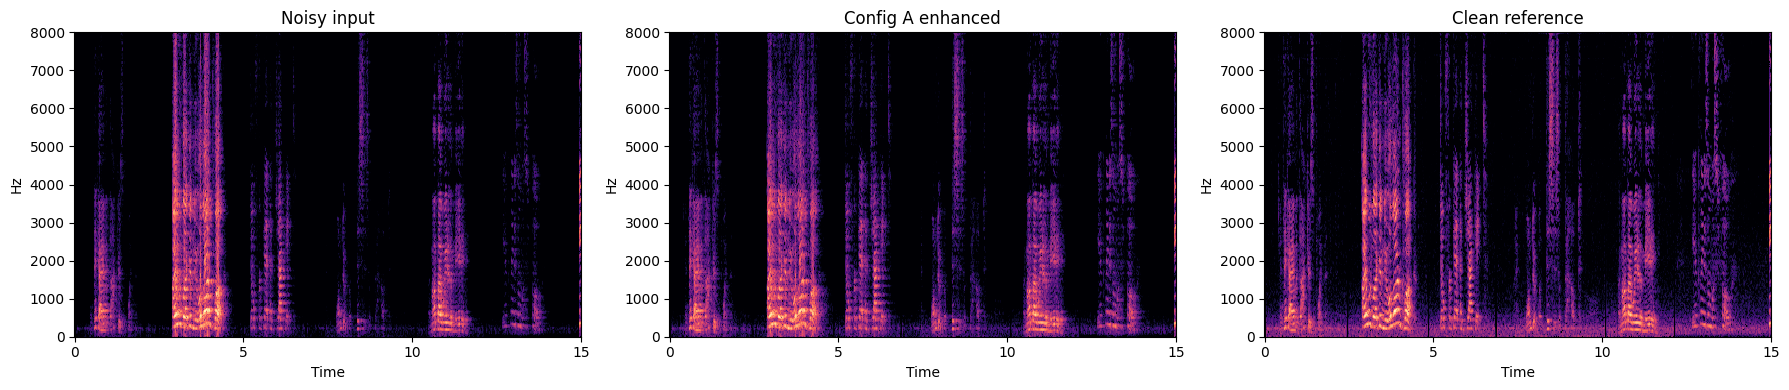

In [55]:
# Spectrogram comparison: noisy vs enhanced vs clean
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

def plot_spec(ax, wav, title):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(wav, n_fft=512, hop_length=160)), ref=np.max)
    librosa.display.specshow(D, sr=SAMPLE_RATE, hop_length=160,
                             x_axis='time', y_axis='hz', ax=ax)
    ax.set_title(title)
    ax.set_ylim(0, 8000)

plot_spec(axes[0], noisy_np,    'Noisy input')
plot_spec(axes[1], enhanced_np, 'Config A enhanced')
plot_spec(axes[2], clean_np,    'Clean reference')
plt.tight_layout()
plt.savefig(os.path.join(ENHANCED_DIR, 'example_spectrogram.png'), dpi=120)
plt.show()

In [56]:
# Listen to audio
print('Noisy input:')
ipd.display(ipd.Audio(noisy_np, rate=SAMPLE_RATE))
print('Config A enhanced:')
ipd.display(ipd.Audio(enhanced_np, rate=SAMPLE_RATE))
print('Clean reference:')
ipd.display(ipd.Audio(clean_np, rate=SAMPLE_RATE))

Noisy input:


Config A enhanced:


Clean reference:


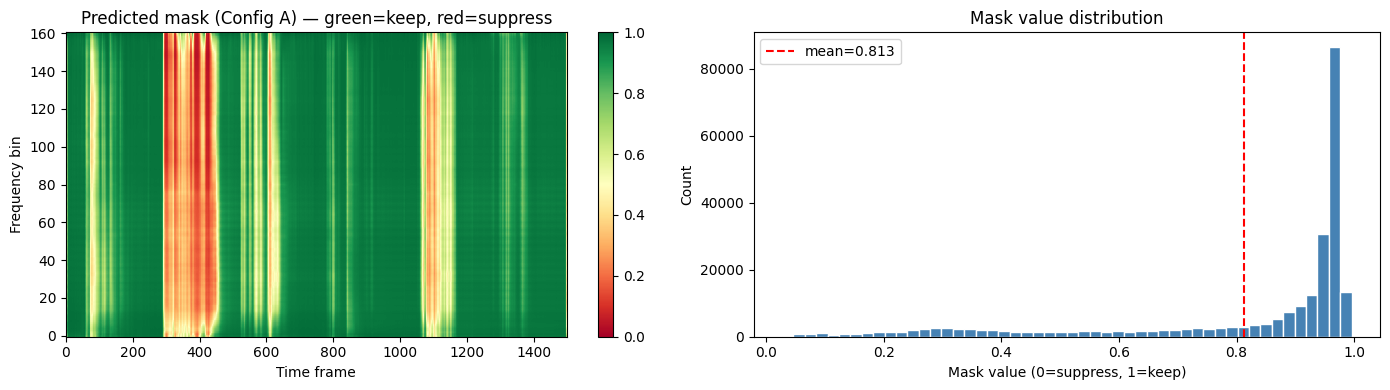

Mask: min=0.0273  max=0.9955  mean=0.8129


In [57]:
# Visualize the predicted mask
mask_np = pred_mask_A.squeeze(0).cpu().numpy()  # (1500, 161)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(mask_np.T, aspect='auto', origin='lower',
                    cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title('Predicted mask (Config A) — green=keep, red=suppress')
axes[0].set_xlabel('Time frame')
axes[0].set_ylabel('Frequency bin')
plt.colorbar(im, ax=axes[0])

axes[1].hist(mask_np.flatten(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Mask value (0=suppress, 1=keep)')
axes[1].set_ylabel('Count')
axes[1].set_title('Mask value distribution')
axes[1].axvline(mask_np.mean(), color='red', linestyle='--',
                label=f'mean={mask_np.mean():.3f}')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f'Mask: min={mask_np.min():.4f}  max={mask_np.max():.4f}  mean={mask_np.mean():.4f}')

## Section 6 — Block 4: Enhance All Test Files

Generate N test samples, enhance with Config A and Config B, save to disk.

Also saves the noisy files (needed for DNSMOS comparison and baseline ONNX).

In [58]:
N_TEST = 100   # number of test samples to enhance
print(f'Enhancing {N_TEST} test samples with Config A and Config B...')

syn = Synthesizer('config_test.yaml')

for i in range(N_TEST):
    data     = syn.generate()
    noisy_np = data['mic'].astype(np.float32)

    # save noisy file — used for DNSMOS baseline and baseline ONNX
    sf.write(os.path.join(ENHANCED_DIR, 'noisy', f'test_{i:04d}.wav'),
             noisy_np, SAMPLE_RATE)

    with torch.no_grad():
        logpow, noisy_mag, noisy_phase = wav_to_features(noisy_np, device)

        # Config A
        enh_A = features_to_wav(model_A(logpow), noisy_mag, noisy_phase)
        sf.write(os.path.join(ENHANCED_DIR, 'configA', f'test_{i:04d}.wav'),
                 enh_A, SAMPLE_RATE)

        # Config B
        enh_B = features_to_wav(model_B(logpow), noisy_mag, noisy_phase)
        sf.write(os.path.join(ENHANCED_DIR, 'configB', f'test_{i:04d}.wav'),
                 enh_B, SAMPLE_RATE)

    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{N_TEST} done')

print('Done!')
print(f'Noisy files  : {len(glob.glob(os.path.join(ENHANCED_DIR, "noisy", "*.wav")))}')
print(f'Config A     : {len(glob.glob(os.path.join(ENHANCED_DIR, "configA", "*.wav")))}')
print(f'Config B     : {len(glob.glob(os.path.join(ENHANCED_DIR, "configB", "*.wav")))}')

Enhancing 100 test samples with Config A and Config B...
  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
Done!
Noisy files  : 100
Config A     : 100
Config B     : 100


## Section 7 — Block 4: Run Baseline ONNX Model

The baseline ONNX model (`enhance.py`) expects:
- `--data_dir` : folder containing `*_mic.wav` AND `*_lpb.wav` (farend) pairs
- `--output_dir` : where to save enhanced files
- `--model_path` : path to the ONNX model file

Since our synthesized test files do not have farend signals, we create silent farend files.
This is valid — our model also uses mic-only input.

In [59]:
# The baseline enhance.py needs paired _mic.wav and _lpb.wav files
# We rename our noisy files to _mic.wav and create silent _lpb.wav files

BASELINE_PREP_DIR = os.path.join(ENHANCED_DIR, 'baseline_input')
BASELINE_OUT_DIR  = os.path.join(ENHANCED_DIR, 'baseline_onnx')
os.makedirs(BASELINE_PREP_DIR, exist_ok=True)
os.makedirs(BASELINE_OUT_DIR,  exist_ok=True)

noisy_files = sorted(glob.glob(os.path.join(ENHANCED_DIR, 'noisy', '*.wav')))
print(f'Preparing {len(noisy_files)} files for baseline ONNX...')

for fpath in noisy_files:
    basename = os.path.splitext(os.path.basename(fpath))[0]  # test_0000
    # read noisy file
    audio, sr = sf.read(fpath)
    # save as _mic.wav
    sf.write(os.path.join(BASELINE_PREP_DIR, f'{basename}_mic.wav'), audio, sr)
    # save silent farend as _lpb.wav (zeros same length)
    silent = np.zeros_like(audio)
    sf.write(os.path.join(BASELINE_PREP_DIR, f'{basename}_lpb.wav'), silent, sr)

print(f'Prepared files in: {BASELINE_PREP_DIR}')
print(f'  _mic.wav files: {len(glob.glob(os.path.join(BASELINE_PREP_DIR, "*_mic.wav")))}')
print(f'  _lpb.wav files: {len(glob.glob(os.path.join(BASELINE_PREP_DIR, "*_lpb.wav")))}')

Preparing 100 files for baseline ONNX...
Prepared files in: /gpfs/helios/home/etais/hpc_bilal/nn_proj/enhanced_audio/baseline_input
  _mic.wav files: 100
  _lpb.wav files: 100


In [60]:
# Run baseline enhance.py
# Arguments: --model_path, --data_dir, --output_dir

print('Running baseline ONNX enhance.py...')
result = subprocess.run(
    [
        'python', ENHANCE_SCRIPT,
        '--model_path', ONNX_MODEL,
        '--data_dir',   BASELINE_PREP_DIR,
        '--output_dir', BASELINE_OUT_DIR,
        # '--output_sr',  '16000',   # ← add this
    ],
    capture_output=True, text=True, cwd=PROJECT_DIR
)

print('STDOUT:', result.stdout[:500] if result.stdout else '(none)')
if result.returncode != 0:
    print('STDERR:', result.stderr[:500])
else:
    n = len(glob.glob(os.path.join(BASELINE_OUT_DIR, '*.wav')))
    print(f'Baseline ONNX enhanced {n} files successfully.')

Running baseline ONNX enhance.py...
STDOUT: (none)
Baseline ONNX enhanced 100 files successfully.


In [61]:
# enhance.py saves at 48kHz by default → resample to 16kHz to match our model
import librosa

baseline_files = glob.glob(os.path.join(BASELINE_OUT_DIR, '*.wav'))
print(f'Resampling {len(baseline_files)} baseline files from 48kHz to 16kHz...')

for fpath in baseline_files:
    audio, sr = sf.read(fpath)
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sf.write(fpath, audio, 16000)

print('Done — all baseline files now at 16kHz')
print(f'Example duration: {len(audio)/16000:.1f} seconds')  # should be ~15

Resampling 100 baseline files from 48kHz to 16kHz...
Done — all baseline files now at 16kHz
Example duration: 15.0 seconds


In [62]:
# Verify baseline output and listen to one example
baseline_files = sorted(glob.glob(os.path.join(BASELINE_OUT_DIR, '*.wav')))
noisy_files_l  = sorted(glob.glob(os.path.join(ENHANCED_DIR, 'noisy', '*.wav')))
configA_files  = sorted(glob.glob(os.path.join(ENHANCED_DIR, 'configA', '*.wav')))

print(f'Baseline enhanced files: {len(baseline_files)}')

if baseline_files and noisy_files_l:
    noisy_wav,    sr = sf.read(noisy_files_l[0])
    baseline_wav, _  = sf.read(baseline_files[0])
    configA_wav,  _  = sf.read(configA_files[0])

    print('Noisy input:')
    ipd.display(ipd.Audio(noisy_wav, rate=sr))
    print('Baseline ONNX enhanced:')
    ipd.display(ipd.Audio(baseline_wav, rate=sr))
    print('Config A (our model) enhanced:')
    ipd.display(ipd.Audio(configA_wav, rate=sr))
else:
    print('No baseline files found — check the cell above for errors.')

Baseline enhanced files: 100
Noisy input:


Baseline ONNX enhanced:


Config A (our model) enhanced:


## Section 8 — Block 5: DNSMOS Evaluation

Run `dnsmos_local.py` on all four sets of audio.

**DNSMOS metrics (all scored 1-5, higher is better):**
- **SIG**: signal quality — how well speech is preserved
- **BAK**: background suppression — how well noise is removed
- **OVRL**: overall quality — primary comparison metric
- **P808_MOS**: perceptual naturalness score

Note: `dnsmos_local.py` must be run from the project directory (where DNSMOS/ folder is).

In [63]:
def run_dnsmos(audio_dir, label):
    """
    Run dnsmos_local.py on a folder of wav files.
    Uses -t (testset_dir) and -o (csv_path) arguments.
    Handles empty results gracefully.
    Returns DataFrame with SIG, BAK, OVRL, P808_MOS columns.
    """
    print(f'Running DNSMOS on: {label}')
    wav_count = len(glob.glob(os.path.join(audio_dir, '*.wav')))
    print(f'  Found {wav_count} wav files in {audio_dir}')

    if wav_count == 0:
        print(f'  WARNING: no wav files found — skipping')
        return None

    output_csv = os.path.join(ENHANCED_DIR, f'dnsmos_{label}.csv')

    result = subprocess.run(
        ['python', DNSMOS_SCRIPT, '-t', audio_dir, '-o', output_csv],
        capture_output=True, text=True, cwd=PROJECT_DIR
    )

    if result.returncode != 0:
        print(f'  ERROR running dnsmos_local.py:')
        print(f'  {result.stderr[:300]}')
        return None

    if not os.path.exists(output_csv):
        print(f'  ERROR: output CSV not created')
        return None

    df = pd.read_csv(output_csv)

    if len(df) == 0 or 'SIG' not in df.columns:
        print(f'  WARNING: empty results. Columns: {list(df.columns)}')
        return None

    print(f'  Files scored : {len(df)}')
    print(f'  SIG          : {df["SIG"].mean():.4f} +/- {df["SIG"].std():.4f}')
    print(f'  BAK          : {df["BAK"].mean():.4f} +/- {df["BAK"].std():.4f}')
    print(f'  OVRL         : {df["OVRL"].mean():.4f} +/- {df["OVRL"].std():.4f}')
    print(f'  P808_MOS     : {df["P808_MOS"].mean():.4f} +/- {df["P808_MOS"].std():.4f}')
    print()
    return df


# Run DNSMOS on all four sets
df_noisy    = run_dnsmos(os.path.join(ENHANCED_DIR, 'noisy'),        'noisy')
df_configA  = run_dnsmos(os.path.join(ENHANCED_DIR, 'configA'),      'configA')
df_configB  = run_dnsmos(os.path.join(ENHANCED_DIR, 'configB'),      'configB')
df_baseline = run_dnsmos(os.path.join(ENHANCED_DIR, 'baseline_onnx'),'baseline_onnx')

Running DNSMOS on: noisy
  Found 100 wav files in /gpfs/helios/home/etais/hpc_bilal/nn_proj/enhanced_audio/noisy
  Files scored : 100
  SIG          : 2.2227 +/- 0.7669
  BAK          : 2.5003 +/- 1.0096
  OVRL         : 1.8548 +/- 0.6605
  P808_MOS     : 2.5717 +/- 0.4304

Running DNSMOS on: configA
  Found 100 wav files in /gpfs/helios/home/etais/hpc_bilal/nn_proj/enhanced_audio/configA
  Files scored : 100
  SIG          : 2.1643 +/- 0.8239
  BAK          : 2.5619 +/- 1.0379
  OVRL         : 1.8642 +/- 0.7110
  P808_MOS     : 2.6419 +/- 0.4768

Running DNSMOS on: configB
  Found 100 wav files in /gpfs/helios/home/etais/hpc_bilal/nn_proj/enhanced_audio/configB
  Files scored : 100
  SIG          : 2.6961 +/- 0.1094
  BAK          : 3.9267 +/- 0.1830
  OVRL         : 2.0927 +/- 0.1215
  P808_MOS     : 2.2514 +/- 0.0947

Running DNSMOS on: baseline_onnx
  Found 100 wav files in /gpfs/helios/home/etais/hpc_bilal/nn_proj/enhanced_audio/baseline_onnx
  Files scored : 100
  SIG          : 

## Section 9 — Results Summary Table

In [64]:
# Build comparison table with improvement over noisy baseline
results = {
    'Noisy (no enhancement)': df_noisy,
    'Baseline ONNX':          df_baseline,
    'Config A (lr=0.005, h=161)': df_configA,
    'Config B (lr=0.001, h=322)': df_configB,
}

noisy_sig  = df_noisy['SIG'].mean()  if df_noisy  is not None else 0
noisy_bak  = df_noisy['BAK'].mean()  if df_noisy  is not None else 0
noisy_ovrl = df_noisy['OVRL'].mean() if df_noisy  is not None else 0

rows = []
for label, df in results.items():
    if df is None:
        rows.append({'Model': label, 'SIG': 'N/A', 'BAK': 'N/A',
                     'OVRL': 'N/A', 'P808_MOS': 'N/A',
                     'ΔSIG': 'N/A', 'ΔBAK': 'N/A', 'ΔOVRL': 'N/A'})
        continue
    rows.append({
        'Model':    label,
        'SIG':      round(df['SIG'].mean(),      3),
        'BAK':      round(df['BAK'].mean(),      3),
        'OVRL':     round(df['OVRL'].mean(),     3),
        'P808_MOS': round(df['P808_MOS'].mean(), 3),
        'ΔSIG':     round(df['SIG'].mean()  - noisy_sig,  3),
        'ΔBAK':     round(df['BAK'].mean()  - noisy_bak,  3),
        'ΔOVRL':    round(df['OVRL'].mean() - noisy_ovrl, 3),
    })

df_summary = pd.DataFrame(rows)
print('=== DNSMOS Results ===')
print(df_summary.to_string(index=False))
print()
print('Δ = improvement over noisy (positive = better than no enhancement)')
df_summary.to_csv(os.path.join(ENHANCED_DIR, 'dnsmos_summary.csv'), index=False)
print(f'Saved to: {ENHANCED_DIR}/dnsmos_summary.csv')

=== DNSMOS Results ===
                     Model   SIG   BAK  OVRL  P808_MOS   ΔSIG  ΔBAK  ΔOVRL
    Noisy (no enhancement) 2.223 2.500 1.855     2.572  0.000 0.000  0.000
             Baseline ONNX 2.240 2.721 1.917     2.567  0.017 0.221  0.062
Config A (lr=0.005, h=161) 2.164 2.562 1.864     2.642 -0.058 0.062  0.009
Config B (lr=0.001, h=322) 2.696 3.927 2.093     2.251  0.473 1.426  0.238

Δ = improvement over noisy (positive = better than no enhancement)
Saved to: /gpfs/helios/home/etais/hpc_bilal/nn_proj/enhanced_audio/dnsmos_summary.csv


## Section 10 — Visualize Results

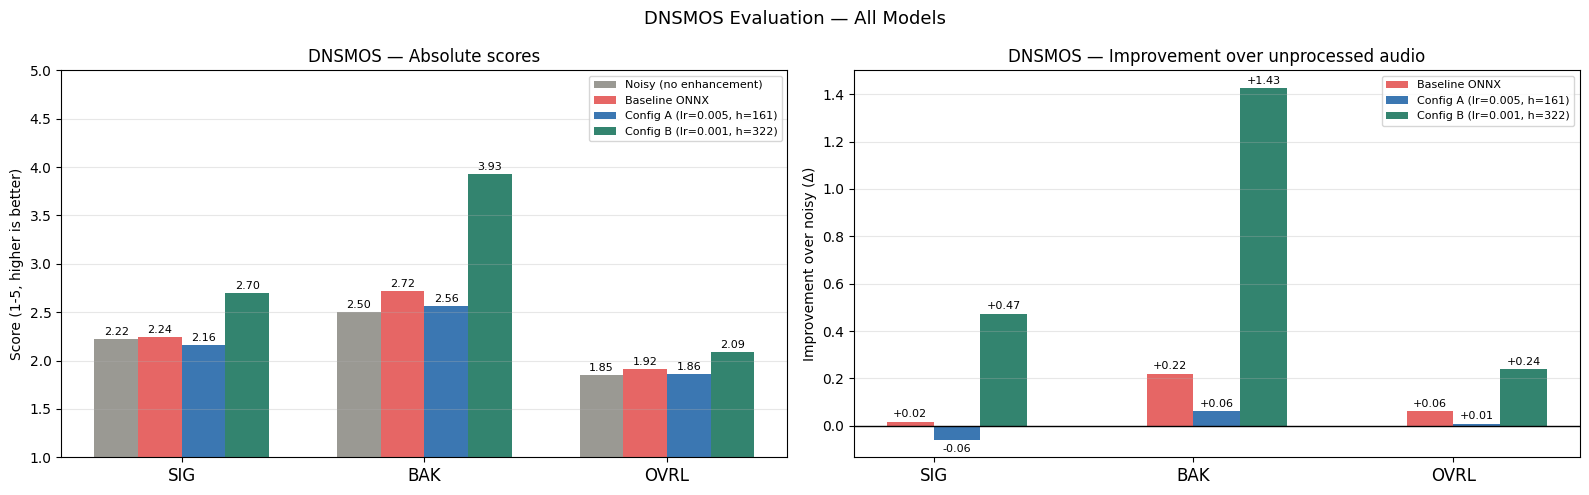

Plot saved.


In [65]:
# Bar chart: absolute scores
valid = {k: v for k, v in results.items() if v is not None}
if len(valid) == 0:
    print('No valid results to plot.')
else:
    metrics = ['SIG', 'BAK', 'OVRL']
    labels  = list(valid.keys())
    colors  = ['#888780', '#E24B4A', '#185FA5', '#0F6E56'][:len(labels)]
    x = np.arange(len(metrics))
    width = 0.18
    n = len(labels)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # absolute scores
    for i, (label, df) in enumerate(valid.items()):
        vals   = [df[m].mean() for m in metrics]
        offset = (i - n/2 + 0.5) * width
        bars   = axes[0].bar(x + offset, vals, width, label=label,
                             color=colors[i], alpha=0.85)
        for bar, val in zip(bars, vals):
            axes[0].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.02,
                         f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics, fontsize=12)
    axes[0].set_ylim(1, 5)
    axes[0].set_ylabel('Score (1-5, higher is better)')
    axes[0].set_title('DNSMOS — Absolute scores')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', alpha=0.3)

    # improvement over noisy
    noisy_vals = {m: valid.get('Noisy (no enhancement)', list(valid.values())[0])[m].mean()
                  for m in metrics} if 'Noisy (no enhancement)' in valid else {m: 0 for m in metrics}
    for i, (label, df) in enumerate(valid.items()):
        if label == 'Noisy (no enhancement)':
            continue
        deltas = [df[m].mean() - noisy_vals[m] for m in metrics]
        offset = (i - n/2 + 0.5) * width
        bars   = axes[1].bar(x + offset, deltas, width, label=label,
                             color=colors[i], alpha=0.85)
        for bar, val in zip(bars, deltas):
            axes[1].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.06,
                         f'{val:+.2f}', ha='center', va='bottom', fontsize=8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics, fontsize=12)
    axes[1].set_ylabel('Improvement over noisy (Δ)')
    axes[1].set_title('DNSMOS — Improvement over unprocessed audio')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].axhline(y=0, color='black', linewidth=1)

    plt.suptitle('DNSMOS Evaluation — All Models', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(ENHANCED_DIR, 'dnsmos_comparison.png'), dpi=120)
    plt.show()
    print('Plot saved.')

In [1]:
# # SIG vs BAK scatter — shows speech preservation vs noise suppression trade-off
# # Ideal: top-right corner (high SIG AND high BAK)
# fig, ax = plt.subplots(figsize=(8, 6))

# scatter_styles = [
#     ('Noisy (no enhancement)',    '#888780', 'o'),
#     ('Baseline ONNX',             '#E24B4A', 's'),
#     ('Config A (lr=0.005, h=161)','#185FA5', '^'),
#     ('Config B (lr=0.001, h=322)','#0F6E56', 'D'),
# ]

# for label, color, marker in scatter_styles:
#     df = results.get(label)
#     if df is None:
#         continue
#     ax.scatter(df['SIG'], df['BAK'], c=color, marker=marker,
#                s=30, alpha=0.4, edgecolors='white', linewidths=0.3, label=label)
#     ax.scatter(df['SIG'].mean(), df['BAK'].mean(), c=color, marker=marker,
#                s=180, edgecolors='black', linewidths=1.5, zorder=5)

# ax.set_xlabel('SIG — Signal quality (higher = better speech)', fontsize=11)
# ax.set_ylabel('BAK — Background suppression (higher = less noise)', fontsize=11)
# ax.set_title('SIG vs BAK trade-off\n(large markers = mean, small = per file)', fontsize=11)
# ax.legend(fontsize=9)
# ax.grid(alpha=0.3)
# ax.set_xlim(1, 5)
# ax.set_ylim(1, 5)
# ax.annotate('Ideal corner', xy=(4.5, 4.5), fontsize=9, color='green')
# plt.tight_layout()
# plt.savefig(os.path.join(ENHANCED_DIR, 'sig_vs_bak.png'), dpi=120)
# plt.show()

## Section 11 — Final Verdict

In [67]:
print('=' * 55)
print('FINAL VERDICT')
print('=' * 55)

for label, df in results.items():
    if df is None:
        print(f'{label:35s} : N/A')
    else:
        print(f'{label:35s} : SIG={df["SIG"].mean():.3f}  BAK={df["BAK"].mean():.3f}  OVRL={df["OVRL"].mean():.3f}')

print()
if df_baseline is not None and df_configA is not None:
    baseline_ovrl = df_baseline['OVRL'].mean()
    best_ovrl  = max(
        df_configA['OVRL'].mean() if df_configA is not None else 0,
        df_configB['OVRL'].mean() if df_configB is not None else 0
    )
    best_label = 'Config A' if (df_configA is not None and
                                df_configA['OVRL'].mean() >= (df_configB['OVRL'].mean() if df_configB is not None else 0)) else 'Config B'
    print(f'Baseline ONNX OVRL  : {baseline_ovrl:.4f}')
    print(f'Our best OVRL       : {best_ovrl:.4f}  ({best_label})')
    print()
    if best_ovrl > baseline_ovrl:
        print(f'We BEAT the baseline by {best_ovrl - baseline_ovrl:.4f} OVRL points!')
    else:
        print(f'We are {baseline_ovrl - best_ovrl:.4f} OVRL points below the baseline.')
else:
    print('Run DNSMOS on all sets first to see the verdict.')

FINAL VERDICT
Noisy (no enhancement)              : SIG=2.223  BAK=2.500  OVRL=1.855
Baseline ONNX                       : SIG=2.240  BAK=2.721  OVRL=1.917
Config A (lr=0.005, h=161)          : SIG=2.164  BAK=2.562  OVRL=1.864
Config B (lr=0.001, h=322)          : SIG=2.696  BAK=3.927  OVRL=2.093

Baseline ONNX OVRL  : 1.9167
Our best OVRL       : 2.0927  (Config B)

We BEAT the baseline by 0.1760 OVRL points!


## Section 12 — Training Loss Curves (from HPC runs)

Config A loss curves:


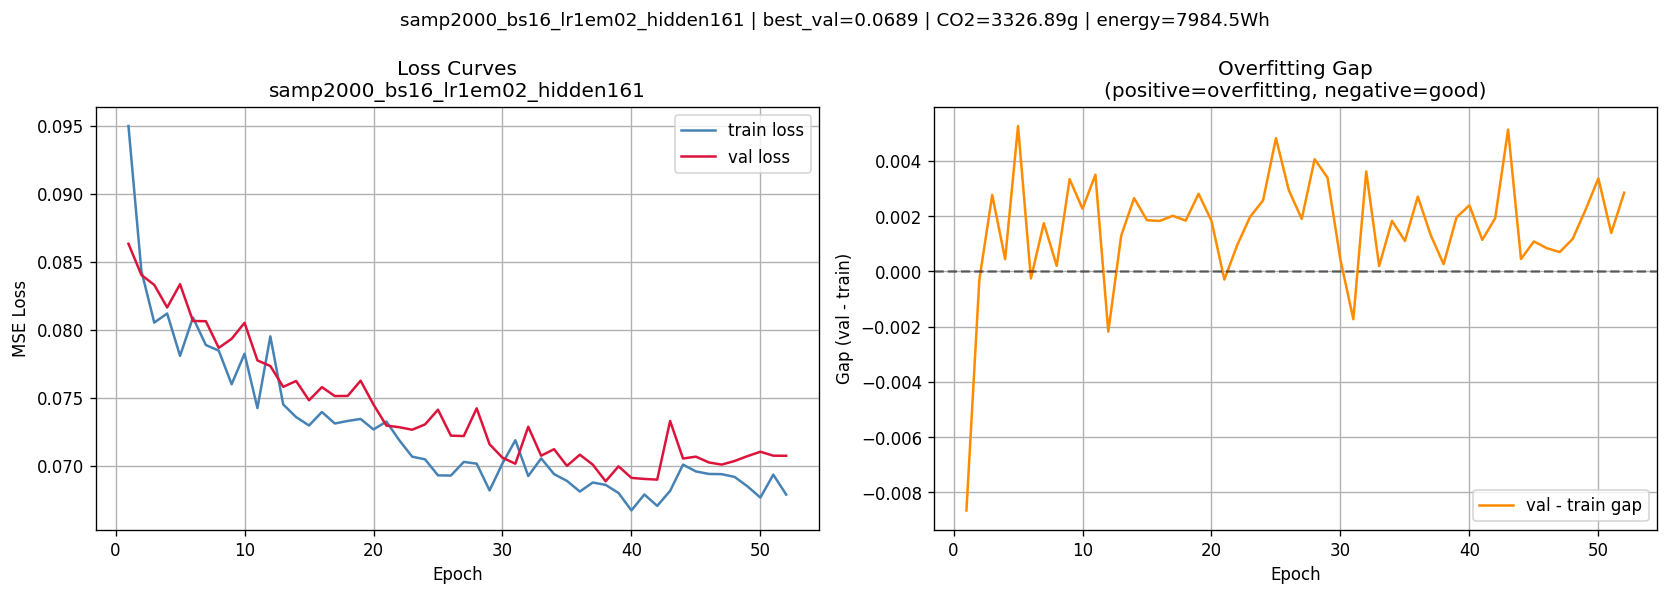

Config B loss curves:


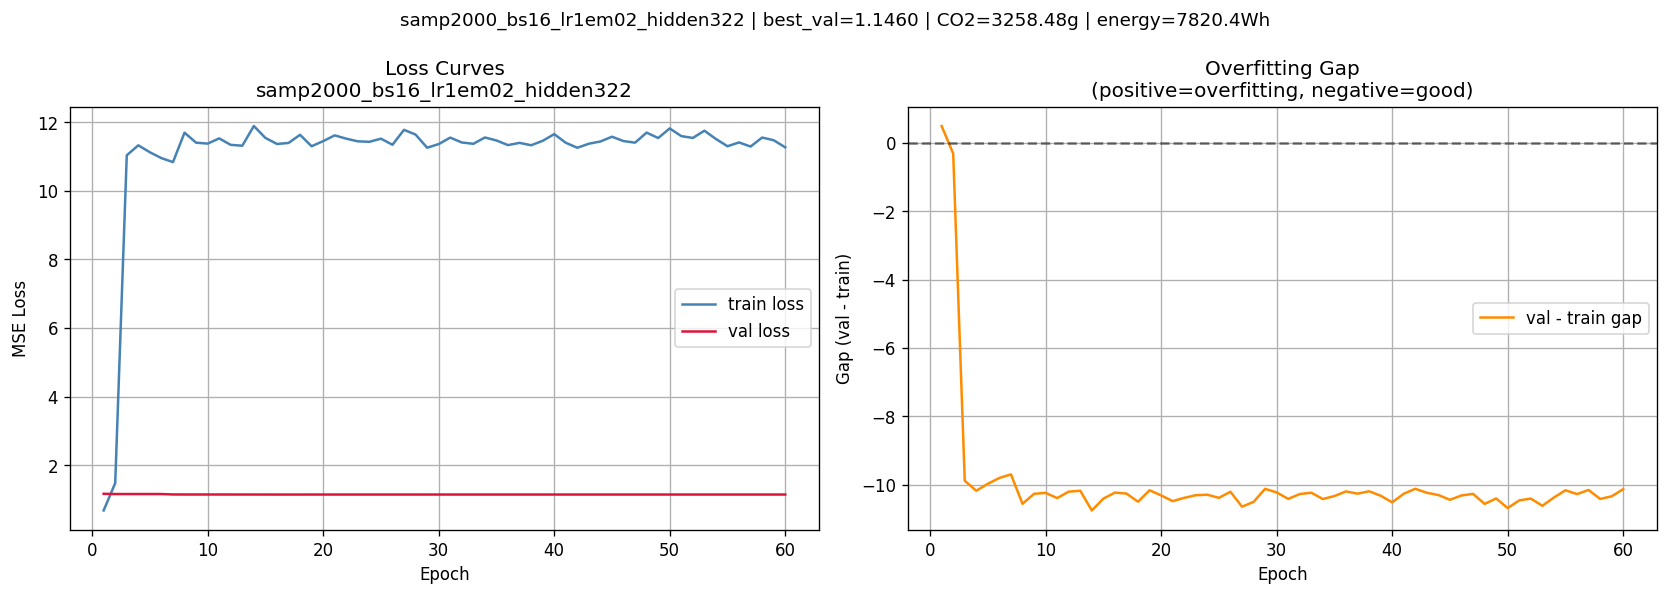

In [68]:
from IPython.display import Image

for label, run_dir in [('Config A', CONFIG_A_DIR), ('Config B', CONFIG_B_DIR)]:
    curve = os.path.join(run_dir, 'loss_curves.png')
    if os.path.exists(curve):
        print(f'{label} loss curves:')
        ipd.display(Image(curve))
    else:
        print(f'{label}: loss_curves.png not found at {curve}')

## Summary

| Block | What was done |
|---|---|
| Block 1 | DataLoader with online synthesis via Synthesizer |
| Block 2 | STFT preprocessing inside `__getitem__`, IRM target computed |
| Block 3 | Two-layer GRU model trained on HPC with DataParallel |
| Block 4 | Predicted mask applied to noisy spectrogram, inverse STFT → enhanced audio |
| Block 5 | DNSMOS scores computed for noisy, Config A, Config B, and baseline ONNX |

In [69]:
# import glob, os
# baseline_dir = os.path.join(ENHANCED_DIR, 'baseline_onnx')
# all_files = glob.glob(os.path.join(baseline_dir, '*'))
# print(f'All files in baseline_onnx: {len(all_files)}')
# for f in all_files[:5]:
#     print(' ', f)

In [70]:
# result = subprocess.run(
#     [
#         'python', ENHANCE_SCRIPT,
#         '--model_path', ONNX_MODEL,
#         '--data_dir',   BASELINE_PREP_DIR,
#         '--output_dir', BASELINE_OUT_DIR,
#         '--output_sr',  '16000',
#     ],
#     capture_output=True, text=True, cwd=PROJECT_DIR
# )
# print('returncode:', result.returncode)
# print('stdout:', result.stdout[:500])
# print('stderr:', result.stderr[:500])

In [71]:
# print('FULL STDERR:')
# print(result.stderr)
# print('FULL STDOUT:')
# print(result.stdout)